In [1]:
# importing different packages
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler # this just standardizes
from sklearn.impute import SimpleImputer

# do this for zips with demographic factors and with der data


In [2]:
ca_count_df = pd.read_pickle("county_data_ca.pkl")
county_dataframe = pd.read_pickle("county_data.pkl")


# # this is the data that is going to be used to cluster the counties
# clustering_data = ca_count_df.drop(columns=['FIPS', 'State', 'Area_Name', 'MEDHHINC_2021'])
# features = list(clustering_data.columns)


# clustering_data.fillna(clustering_data.mean(), inplace=True)  # Replace NaN with column mean
# imputer = SimpleImputer(strategy='mean')
# data_imputed = imputer.fit_transform(clustering_data)
# data_copy = pd.DataFrame(data_imputed, columns=clustering_data.columns)

# # Now scale the data (all columns should be numeric and complete)
# scaler = StandardScaler()
# clustering_data_scaled = scaler.fit_transform(data_copy)
# clustering_data_scaled = pd.DataFrame(clustering_data_scaled, columns=data_copy.columns)
# num = 3

# # columns not to train on
# cluster_columns = ['UMAP_Cluster', 'PCA_Cluster', 'tSNE_Cluster', 'Cluster', 'RF_Cluster']

In [4]:
df1 = pd.read_csv("california_energy_data.csv")
ca_count_df = pd.read_pickle("county_data_ca.pkl")
df1.fillna(0, inplace=True)
df1["FIPS"] = df1["FIPS"].astype(int).astype(str).str.zfill(5)
ca_count_df["FIPS"] = ca_count_df["FIPS"].astype(str).str.zfill(5)
df = df1.merge(ca_count_df, on="FIPS", how="outer")

# print(ca_count_df.columns)

per_capita_columns = [
    'white', 'black', 'native', 'asian', 'pacific', 'other', 'two_or_more',
]

percent_columns = ['Percent of adults with less than a high school diploma, 2018-22',
    'Percent of adults with a high school diploma only, 2018-22',
    "Percent of adults completing some college or associate's degree, 2018-22",
    "Percent of adults with a bachelor's degree or higher, 2018-22",
    'Med_HH_Income_Percent_of_State_Total_2021', 'Unemployment_rate_2022',
    'PCTPOVALL_2021', 'R_NATURAL_CHG_2023',
    ]

unchanged_columns = [
    'FIPS', 'State', 'Area_Name',
    'GHI (kWh/m²/day)',
    'Wind Speed (10m) (m/s)', 'Wind Speed (50m) (m/s)',
    'Urban_Influence_Code_2013', '2023 Rural-urban Continuum Code',
    'POP_ESTIMATE_2023', 'NATURAL_CHG_2023', 'NET_MIG_2023',
    'GQ_ESTIMATES_2023', 'POVALL_2021',
    'Civilian_labor_force_2022',
    'Median_Household_Income_2021', 'lng', 'lat'
]


columns_to_keep = percent_columns + per_capita_columns + unchanged_columns + ['total_pop']
df_filtered = df[columns_to_keep].copy()

for col in per_capita_columns:
    df_filtered[col] = df_filtered[col] / df_filtered['total_pop']

for col in percent_columns:
    df_filtered[col] = df_filtered[col] / 100

df_normalized = df_filtered.drop(columns=['State', 'Area_Name'])


# Replace infinite values with NaN
df_normalized = df_normalized.replace([np.inf, -np.inf], np.nan)

# Fill NaNs only in numeric columns with the column mean
numeric_cols = df_normalized.select_dtypes(include=[np.number]).columns
df_normalized[numeric_cols] = df_normalized[numeric_cols].fillna(df_normalized[numeric_cols].mean())


print(df1.head)


<bound method NDFrame.head of      FIPS   County     t_cap     t_hh     t_rd      t_rsa   t_ttlh  \
0   06001  alameda  225785.0  14449.2  14626.0  934441.09  21771.3   
1   06003        0       0.0      0.0      0.0       0.00      0.0   
2   06005        0       0.0      0.0      0.0       0.00      0.0   
3   06007        0       0.0      0.0      0.0       0.00      0.0   
4   06009        0       0.0      0.0      0.0       0.00      0.0   
..    ...      ...       ...      ...      ...        ...      ...   
57  06107   tulare       0.0      0.0      0.0       0.00      0.0   
58  06109        0       0.0      0.0      0.0       0.00      0.0   
59  06111  ventura       0.0      0.0      0.0       0.00      0.0   
60  06113     yolo    1500.0     80.0     77.0    4656.63    118.6   
61  06115        0       0.0      0.0      0.0       0.00      0.0   

    t_retrofit  t_retro_yr  t_offshore  ...  Inverter Model 24  \
0          0.0         0.0         0.0  ...                0.0 

In [5]:
df_normalized = df_normalized.drop(columns=['FIPS'])
features = list(df_normalized.columns)
df_normalized.fillna(df_normalized.mean(), inplace=True)  # Replace NaN with column mean
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(df_normalized)
data_copy = pd.DataFrame(data_imputed, columns=df_normalized.columns)

# Now scale the data (all columns should be numeric and complete)
scaler = StandardScaler()
clustering_data_scaled = scaler.fit_transform(data_copy)
clustering_data_scaled = pd.DataFrame(clustering_data_scaled, columns=data_copy.columns)
num = 3

# columns not to train on
cluster_columns = ['UMAP_Cluster', 'PCA_Cluster', 'tSNE_Cluster', 'Cluster', 'RF_Cluster']

In [6]:

import umap
from sklearn.cluster import KMeans

# UMAP dimensionality reduction
umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
umap_data = umap_reducer.fit_transform(clustering_data_scaled)

# Clustering the UMAP-reduced data with k-means
kmeans = KMeans(n_clusters=num, random_state=42, n_init="auto")
umap_clusters = kmeans.fit_predict(umap_data)

# Add cluster labels to the dataframe
clustering_data_scaled['UMAP_Cluster'] = umap_clusters



from sklearn.decomposition import PCA

# PCA dimensionality reduction
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(clustering_data_scaled.drop(columns=cluster_columns, errors='ignore'))

# Clustering the PCA-reduced data with k-means
kmeans = KMeans(n_clusters=num, random_state=42, n_init="auto")
pca_clusters = kmeans.fit_predict(pca_data)

# Add cluster labels to the dataframe
clustering_data_scaled['PCA_Cluster'] = pca_clusters

# Perform PCA
pca_3d = PCA(n_components=3, random_state=42)
pca_3d_scaled = pca_3d.fit_transform(clustering_data_scaled.drop(columns=cluster_columns, errors='ignore'))


from sklearn.manifold import TSNE

# t-SNE dimensionality reduction
tsne = TSNE(n_components=3, random_state=42)
tsne_data = tsne.fit_transform(clustering_data_scaled.drop(columns=cluster_columns, errors='ignore'))

# Clustering the t-SNE-reduced data with k-means
kmeans = KMeans(n_clusters=num, random_state=42, n_init="auto")
tsne_clusters = kmeans.fit_predict(tsne_data)

# Add cluster labels to the dataframe
clustering_data_scaled['tSNE_Cluster'] = tsne_clusters




from sklearn.ensemble import RandomForestClassifier
import numpy as np

kmeans = KMeans(n_clusters=num, random_state=42)
clustering_data_scaled['Cluster'] = kmeans.fit_predict(clustering_data_scaled.drop(columns=cluster_columns, errors='ignore'))
rf = RandomForestClassifier(random_state=42)
rf.fit(clustering_data_scaled.drop(columns = cluster_columns, errors='ignore'), clustering_data_scaled['Cluster'])

importances = rf.feature_importances_
top_features_idx = np.argsort(importances)[-5:]  # Indices of top 5 features
top_features = clustering_data_scaled.iloc[:, top_features_idx]
print(clustering_data_scaled.columns)

kmeans = KMeans(n_clusters=num, random_state=42)
rf_clusters = kmeans.fit_predict(top_features)

clustering_data_scaled['RF_Cluster'] = rf_clusters

# Using PCA for dimensionality reduction of full dataset for visualization
pca_full = PCA(n_components=3)
pca_full_components = pca_full.fit_transform(clustering_data_scaled.drop(columns=cluster_columns, errors='ignore'))

# Reduce dimensions to 2D for visualization
pca = PCA(n_components=3)
pca_components = pca.fit_transform(top_features)


/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Index(['Percent of adults with less than a high school diploma, 2018-22',
       'Percent of adults with a high school diploma only, 2018-22',
       'Percent of adults completing some college or associate's degree, 2018-22',
       'Percent of adults with a bachelor's degree or higher, 2018-22',
       'Med_HH_Income_Percent_of_State_Total_2021', 'Unemployment_rate_2022',
       'PCTPOVALL_2021', 'R_NATURAL_CHG_2023', 'white', 'black', 'native',
       'asian', 'pacific', 'other', 'two_or_more', 'GHI (kWh/m²/day)',
       'Wind Speed (10m) (m/s)', 'Wind Speed (50m) (m/s)',
       'Urban_Influence_Code_2013', '2023 Rural-urban Continuum Code',
       'POP_ESTIMATE_2023', 'NATURAL_CHG_2023', 'NET_MIG_2023',
       'GQ_ESTIMATES_2023', 'POVALL_2021', 'Civilian_labor_force_2022',
       'Median_Household_Income_2021', 'lng', 'lat', 'total_pop',
       'UMAP_Cluster', 'PCA_Cluster', 'tSNE_Cluster', 'Cluster'],
      dtype='object')


/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


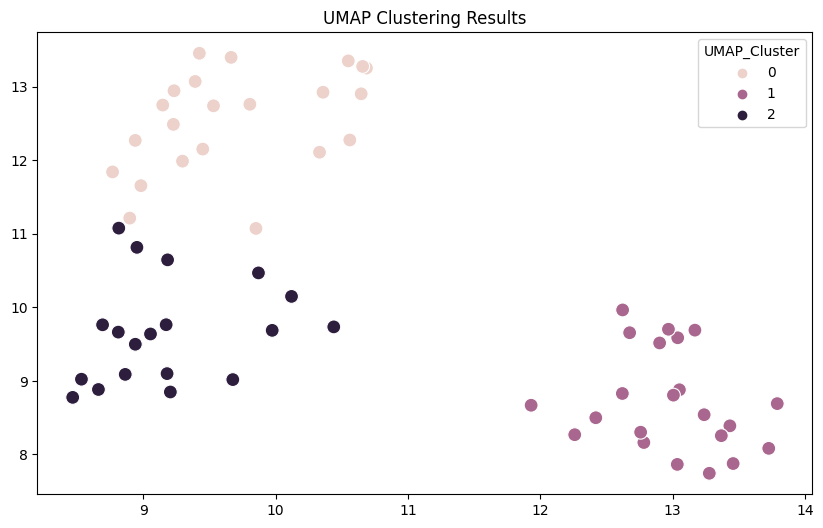

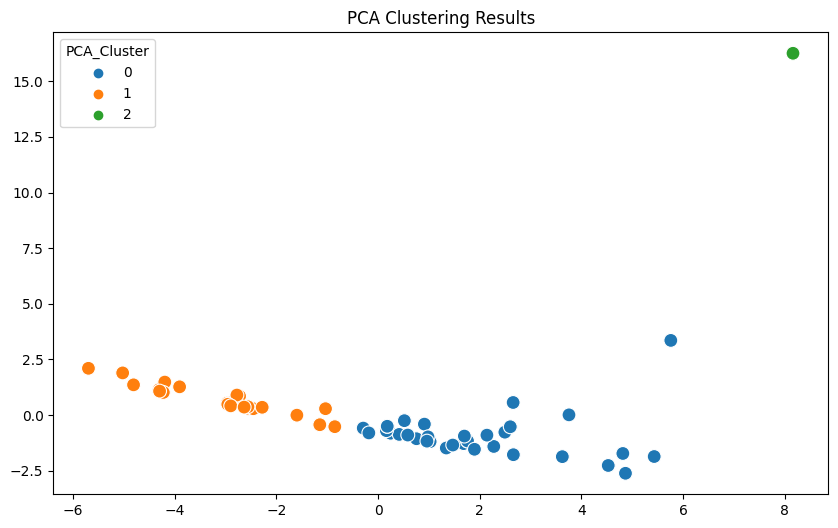

[0.51250846 0.36938924 0.09768581]


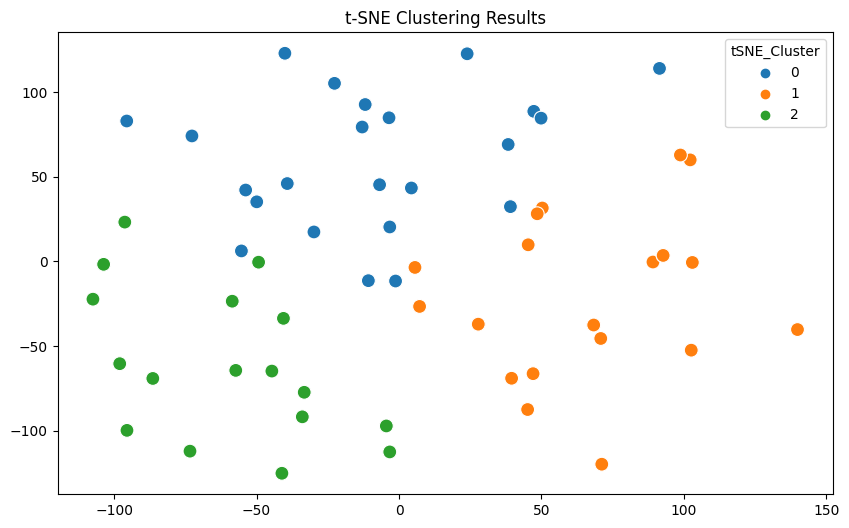

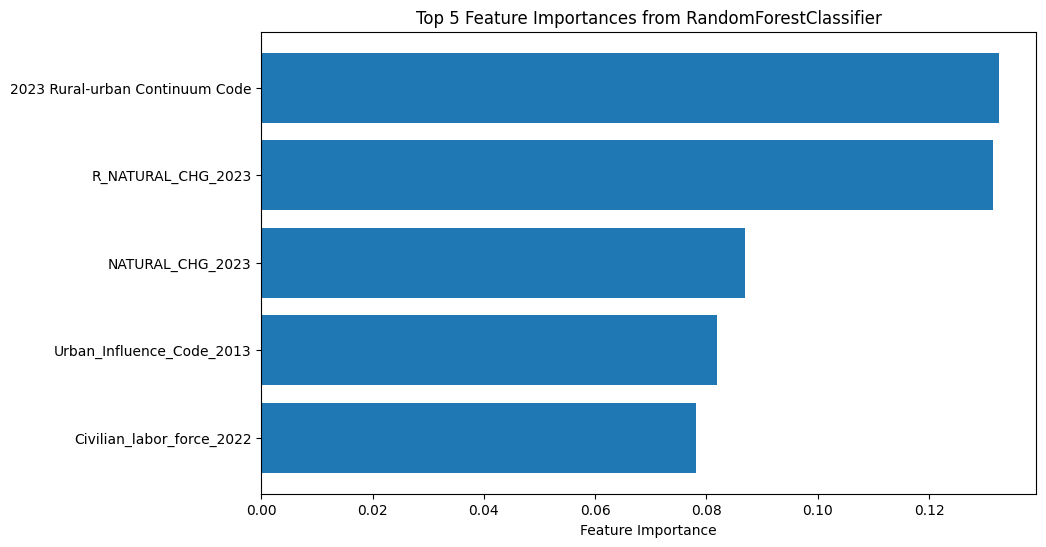

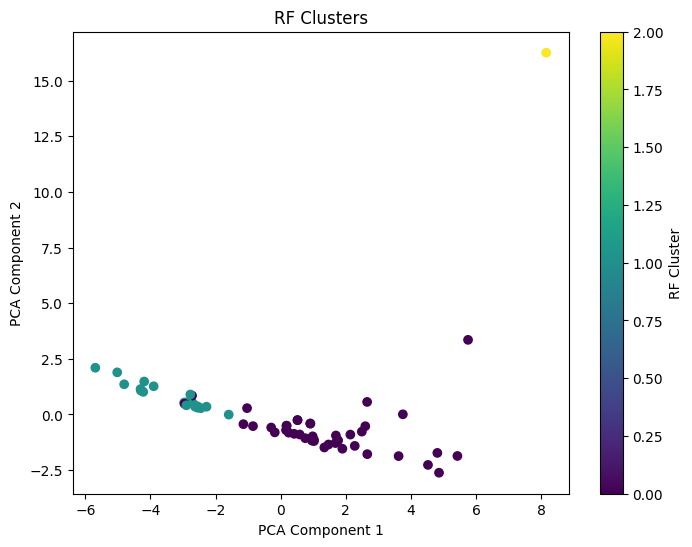

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# UMAP
plt.figure(figsize=(10, 6))
sns.scatterplot(x=umap_data[:, 0], y=umap_data[:, 1], hue=clustering_data_scaled['UMAP_Cluster'], s=100)
plt.title('UMAP Clustering Results')
plt.show()

# PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=clustering_data_scaled['PCA_Cluster'], palette='tab10', s=100)
plt.title('PCA Clustering Results')
plt.show()

print(pca.explained_variance_ratio_)

# 3D PCA
import matplotlib.colors as mcolors
import plotly.express as px
start_color = "red"
end_color = "blue"
values = np.linspace(0, 1, 59)
color_gradient = mcolors.LinearSegmentedColormap.from_list("my_gradient", [start_color, end_color], N=59)
color_list = [color_gradient(value) for value in values]
clustering_data_scaled['PCA_Cluster'] = pca_clusters
fig = px.scatter_3d(
    x=pca_3d_scaled[:, 0], y=pca_3d_scaled[:, 1], z=pca_3d_scaled[:, 2],
    color_discrete_map={0: 'red', 1: 'green', 2: 'blue'},
    color=clustering_data_scaled['PCA_Cluster'],
    labels={'x': 'PC1', 'y': 'PC2', 'z': 'PC3'}
)
fig.update_layout(showlegend=False)
fig.show()

# t-SNE
plt.figure(figsize=(10, 6))
sns.scatterplot(x=tsne_data[:, 0], y=tsne_data[:, 1], hue=clustering_data_scaled['tSNE_Cluster'], palette='tab10', s=100)
plt.title('t-SNE Clustering Results')
plt.show()

# RandomForest
plt.figure(figsize=(10, 6))
plt.barh(clustering_data_scaled.columns[top_features_idx], importances[top_features_idx])
plt.xlabel('Feature Importance')
plt.title('Top 5 Feature Importances from RandomForestClassifier')
plt.show()


# Plotting the RF clusters
plt.figure(figsize=(8, 6))
plt.scatter(pca_full_components[:, 0], pca_full_components[:, 1], c=clustering_data_scaled['RF_Cluster'], cmap='viridis')
plt.title('RF Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='RF Cluster')
plt.show()


Step 1: Did dimensionality reduction using PCA, UMAP, and t-SNE.

Step 2: Clustered the counties based on the reduced dimensions with KMeans.

Found 12 missing values. Applying imputation.


/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/opt/a

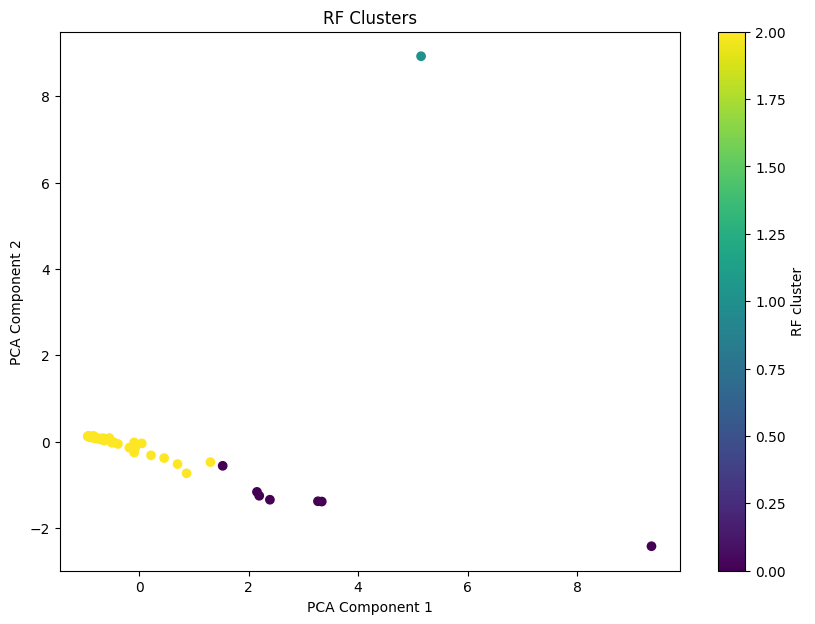

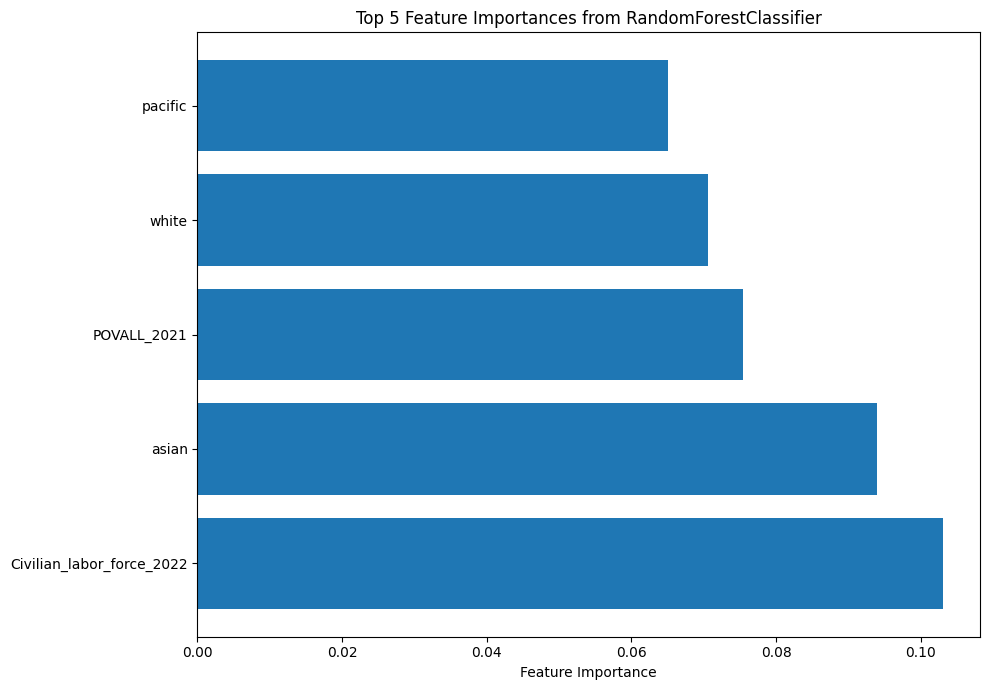

/var/folders/z3/7v87dnm11ds6n_6j078pc3qw0000gn/T/ipykernel_49813/250219044.py:201: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



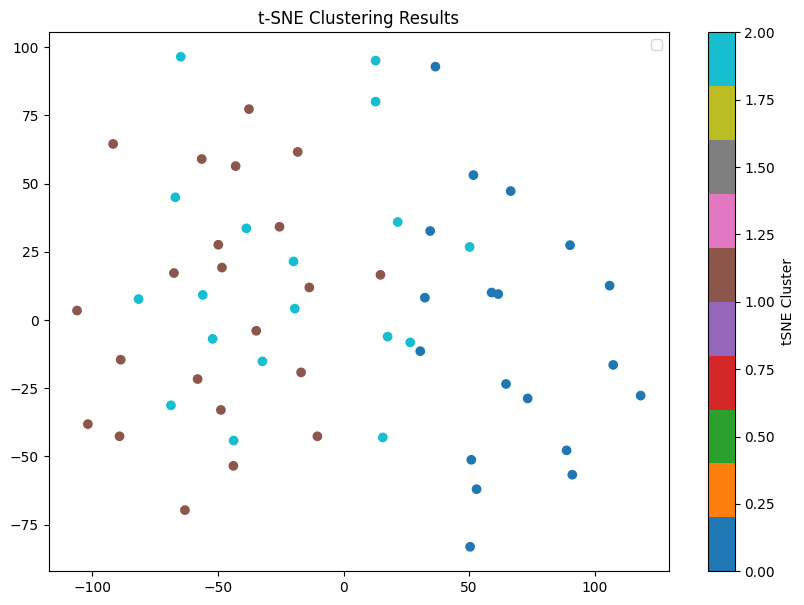

/var/folders/z3/7v87dnm11ds6n_6j078pc3qw0000gn/T/ipykernel_49813/250219044.py:209: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



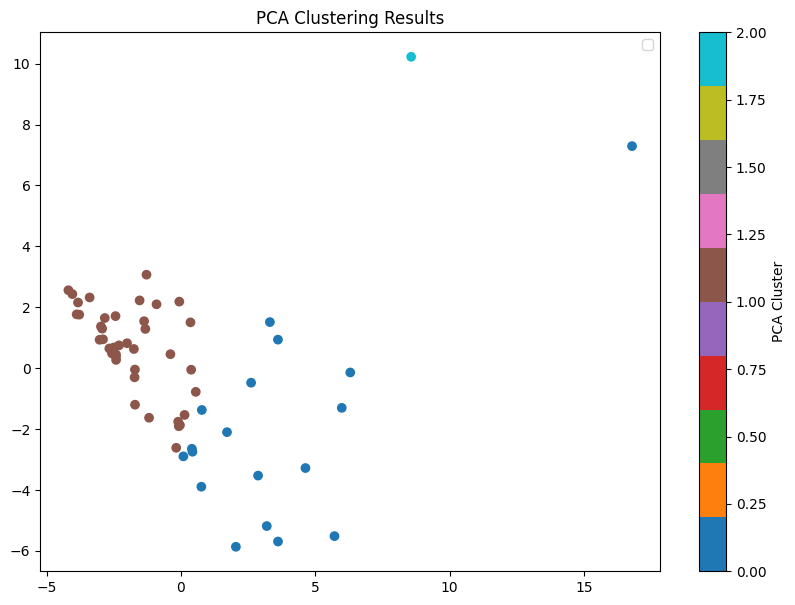

/var/folders/z3/7v87dnm11ds6n_6j078pc3qw0000gn/T/ipykernel_49813/250219044.py:217: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



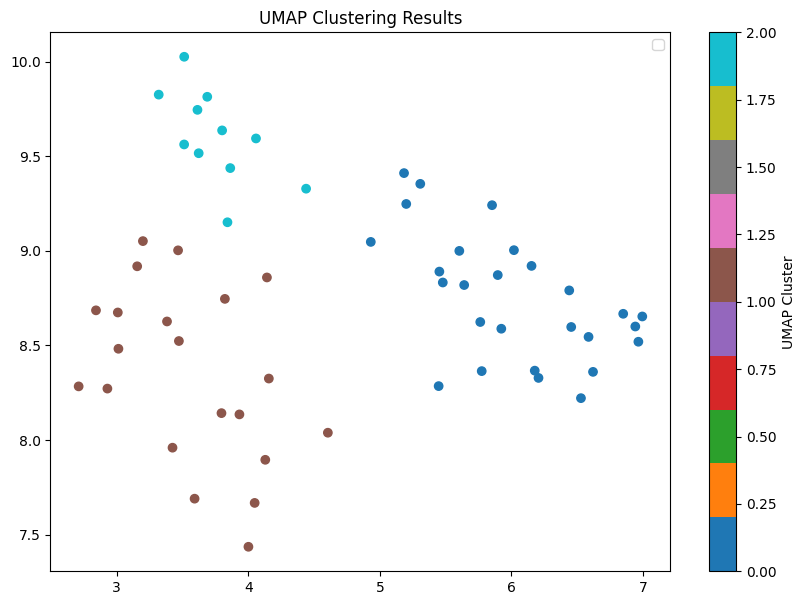

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
import umap

def unsupervised_analysis(data, n_clusters=10, random_state=42, plot = True):
    """Perform dimensionality reduction, clustering, and feature importance analysis."""
    # Preprocessing - handle categorical features and missing values
    data_copy = data.copy()

    # Check for missing values
    missing_values = data_copy.isna().sum().sum()
    if missing_values > 0:
        print(f"Found {missing_values} missing values. Applying imputation.")

    # Identify numeric and categorical columns
    categorical_cols = data_copy.select_dtypes(exclude=['number']).columns.tolist()

    # Handle categorical data using one-hot encoding
    if categorical_cols:
        data_copy = pd.get_dummies(data_copy, columns=categorical_cols)

    # Handle missing values using imputation
    imputer = SimpleImputer(strategy='mean')
    data_imputed = imputer.fit_transform(data_copy)
    data_copy = pd.DataFrame(data_imputed, columns=data_copy.columns)

    # Now scale the data (all columns should be numeric and complete)
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data_copy)
    data_df = pd.DataFrame(data_scaled, columns=data_copy.columns)

    # Rest of your code remains the same
    # Dimensionality reduction
    # PCA
    pca = PCA(n_components=min(3, data_df.shape[1]), random_state=random_state)
    pca_data = pca.fit_transform(data_df.drop(columns=cluster_columns, errors='ignore'))


    # t-SNE (only if we have enough samples)
    if data_df.shape[0] > 5:
        tsne = TSNE(n_components=min(3, data_df.shape[1]), random_state=random_state,
                   perplexity=min(30, data_df.shape[0]//5))
        tsne_data = tsne.fit_transform(data_df.drop(columns=cluster_columns, errors='ignore'))

    else:
        tsne_data = pca_data.copy()  # Fallback to PCA if sample size is too small

    # UMAP
    n_neighbors = min(15, data_df.shape[0]-1)  # Ensure n_neighbors is less than sample size
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=0.1,
                       n_components=min(3, data_df.shape[1]), random_state=random_state)
    umap_data = reducer.fit_transform(data_df.drop(columns=cluster_columns, errors='ignore'))


    # Adjust number of clusters if needed (can't have more clusters than data points)
    n_clusters = min(n_clusters, data_df.shape[0])

    # Clustering
    kmeans_pca = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")
    kmeans_tsne = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")
    kmeans_umap = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")

    pca_clusters = kmeans_pca.fit_predict(pca_data)
    tsne_clusters = kmeans_tsne.fit_predict(tsne_data)
    umap_clusters = kmeans_umap.fit_predict(umap_data)

    # Add clusters to dataframe
    data_df['PCA_Cluster'] = pca_clusters
    data_df['tSNE_Cluster'] = tsne_clusters
    data_df['UMAP_Cluster'] = umap_clusters

    # Feature importance with Random Forest
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
    data_df['Cluster'] = kmeans.fit_predict(data_scaled)

    rf = RandomForestClassifier(random_state=random_state)
    X = data_df.drop(columns=cluster_columns, errors='ignore')
    y = data_df['Cluster']
    rf.fit(X, y)

    # Get feature importances
    importances = rf.feature_importances_
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    # Get top features (limit to max 5 or fewer if fewer features exist)
    n_top = min(5, len(feature_importance))
    top_features = feature_importance.head(n_top)
    top_feature_cols = top_features['Feature'].tolist()

    # Use RF to cluster based on top features
    top_feature_data = data_df[top_feature_cols]
    kmeans_rf = KMeans(n_clusters=n_clusters, random_state=random_state)
    rf_clusters = kmeans_rf.fit_predict(top_feature_data)
    data_df['RF_Cluster'] = rf_clusters

    # Visualizations
    # Plot RF Clusters
    pca_viz = PCA(n_components=0.9, random_state=random_state)
    pca_components = pca_viz.fit_transform(top_feature_data)


    # t-SNE (only if we have enough samples)
    if data_df.shape[0] > 5:
        tsne = TSNE(n_components=min(3, data_df.shape[1]), random_state=random_state,
                   perplexity=min(30, data_df.shape[0]//5))
        tsne_data = tsne.fit_transform(data_scaled)
    else:
        tsne_data = pca_data.copy()  # Fallback to PCA if sample size is too small

    # UMAP
    n_neighbors = min(15, data_df.shape[0]-1)  # Ensure n_neighbors is less than sample size
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=0.1,
                       n_components=min(3, data_df.shape[1]), random_state=random_state)
    umap_data = reducer.fit_transform(data_scaled)

    # Adjust number of clusters if needed (can't have more clusters than data points)
    n_clusters = min(n_clusters, data_df.shape[0])

    # Clustering
    kmeans_pca = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")
    kmeans_tsne = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")
    kmeans_umap = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")

    pca_clusters = kmeans_pca.fit_predict(pca_data)
    tsne_clusters = kmeans_tsne.fit_predict(tsne_data)
    umap_clusters = kmeans_umap.fit_predict(umap_data)

    # Add clusters to dataframe
    data_df['PCA_Cluster'] = pca_clusters
    data_df['tSNE_Cluster'] = tsne_clusters
    data_df['UMAP_Cluster'] = umap_clusters

    # Feature importance with Random Forest
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
    data_df['Cluster'] = kmeans.fit_predict(data_scaled)

    rf = RandomForestClassifier(random_state=random_state)
    X = data_df.drop(columns=cluster_columns, errors = "ignore")
    y = data_df['Cluster']
    rf.fit(X, y)

    # Get feature importances
    importances = rf.feature_importances_
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    # Get top features (limit to max 5 or fewer if fewer features exist)
    n_top = min(5, len(feature_importance))
    top_features = feature_importance.head(n_top)
    top_feature_cols = top_features['Feature'].tolist()

    # Use RF to cluster based on top features
    top_feature_data = data_df[top_feature_cols]
    kmeans_rf = KMeans(n_clusters=n_clusters, random_state=random_state)
    rf_clusters = kmeans_rf.fit_predict(top_feature_data)
    data_df['RF_Cluster'] = rf_clusters

    # Visualizations
    # Plot RF Clusters
    pca_viz = PCA(n_components=2, random_state=random_state)
    pca_components = pca_viz.fit_transform(top_feature_data)

    pca_viz_3d = PCA(n_components=3, random_state=random_state)
    pca_components = pca_viz_3d.fit_transform(top_feature_data)

    if plot:

        plt.figure(figsize=(10, 7))
        plt.scatter(pca_components[:, 0], pca_components[:, 1], c=rf_clusters, cmap='viridis')
        plt.colorbar(label='RF cluster')
        plt.xlabel('PCA Component 1')
        plt.ylabel('PCA Component 2')
        plt.title('RF Clusters')
        plt.show()

        # Plot Feature Importances
        plt.figure(figsize=(10, 7))
        plt.barh(top_features['Feature'], top_features['Importance'])
        plt.xlabel('Feature Importance')
        plt.title('Top 5 Feature Importances from RandomForestClassifier')
        plt.tight_layout()
        plt.show()

        # Plot t-SNE clusters
        plt.figure(figsize=(10, 7))
        plt.scatter(tsne_data[:, 0], tsne_data[:, 1], c=tsne_clusters, cmap='tab10')
        plt.colorbar(label='tSNE Cluster')
        plt.title('t-SNE Clustering Results')
        plt.legend()
        plt.show()

        # Plot PCA clusters
        plt.figure(figsize=(10, 7))
        plt.scatter(pca_data[:, 0], pca_data[:, 1], c=pca_clusters, cmap='tab10')
        plt.colorbar(label='PCA Cluster')
        plt.title('PCA Clustering Results')
        plt.legend()
        plt.show()

        # Plot UMAP clusters
        plt.figure(figsize=(10, 7))
        plt.scatter(umap_data[:, 0], umap_data[:, 1], c=umap_clusters, cmap='tab10')
        plt.colorbar(label='UMAP Cluster')
        plt.title('UMAP Clustering Results')
        plt.legend()
        plt.show()


    return {
        'data_with_clusters': data_df,
        'pca_data': pca_data,
        'tsne_data': tsne_data,
        'umap_data': umap_data,
        'feature_importance': feature_importance,
        'top_features': top_features
    }

# Example usage:
results = unsupervised_analysis(ca_count_df, n_clusters=3)


In [9]:
fips_to_name = {
    '06001': 'Alameda', '06003': 'Alpine', '06005': 'Amador', '06007': 'Butte',
    '06009': 'Calaveras', '06011': 'Colusa', '06013': 'Contra Costa', '06015': 'Del Norte',
    '06017': 'El Dorado', '06019': 'Fresno', '06021': 'Glenn', '06023': 'Humboldt',
    '06025': 'Imperial', '06027': 'Inyo', '06029': 'Kern', '06031': 'Kings',
    '06033': 'Lake', '06035': 'Lassen', '06037': 'Los Angeles', '06039': 'Madera',
    '06041': 'Marin', '06043': 'Mariposa', '06045': 'Mendocino', '06047': 'Merced',
    '06049': 'Modoc', '06051': 'Mono', '06053': 'Monterey', '06055': 'Napa',
    '06057': 'Nevada', '06059': 'Orange', '06061': 'Placer', '06063': 'Plumas',
    '06065': 'Riverside', '06067': 'Sacramento', '06069': 'San Benito', '06071': 'San Bernardino',
    '06073': 'San Diego', '06075': 'San Francisco', '06077': 'San Joaquin', '06079': 'San Luis Obispo',
    '06081': 'San Mateo', '06083': 'Santa Barbara', '06085': 'Santa Clara', '06087': 'Santa Cruz',
    '06089': 'Shasta', '06091': 'Sierra', '06093': 'Siskiyou', '06095': 'Solano',
    '06097': 'Sonoma', '06099': 'Stanislaus', '06101': 'Sutter', '06103': 'Tehama',
    '06105': 'Trinity', '06107': 'Tulare', '06109': 'Tuolumne', '06111': 'Ventura',
    '06113': 'Yolo', '06115': 'Yuba'
}


Found 12 missing values. Applying imputation.


/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/opt/a

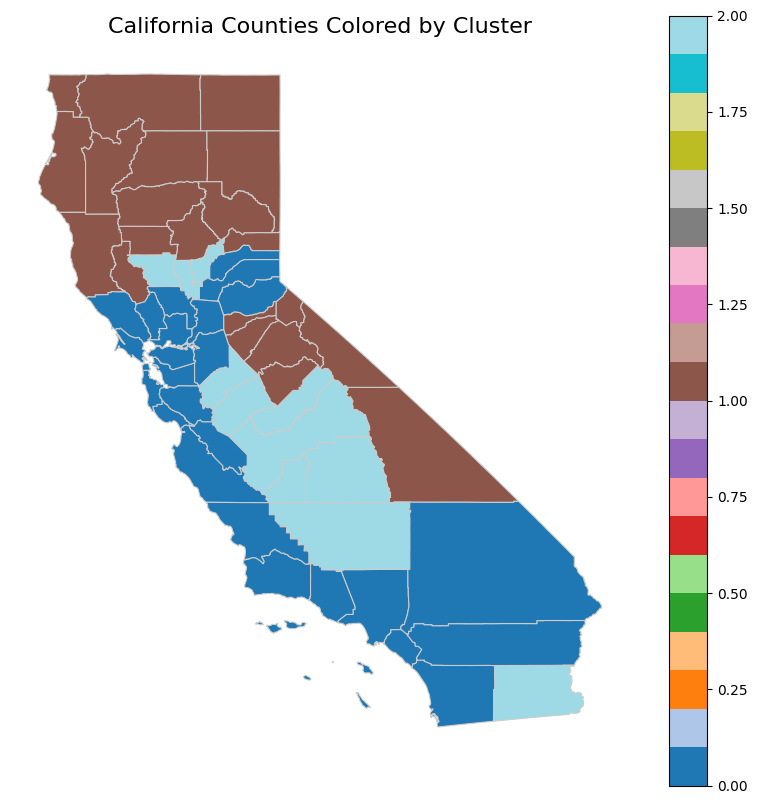

Found 12 missing values. Applying imputation.


/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/opt/a

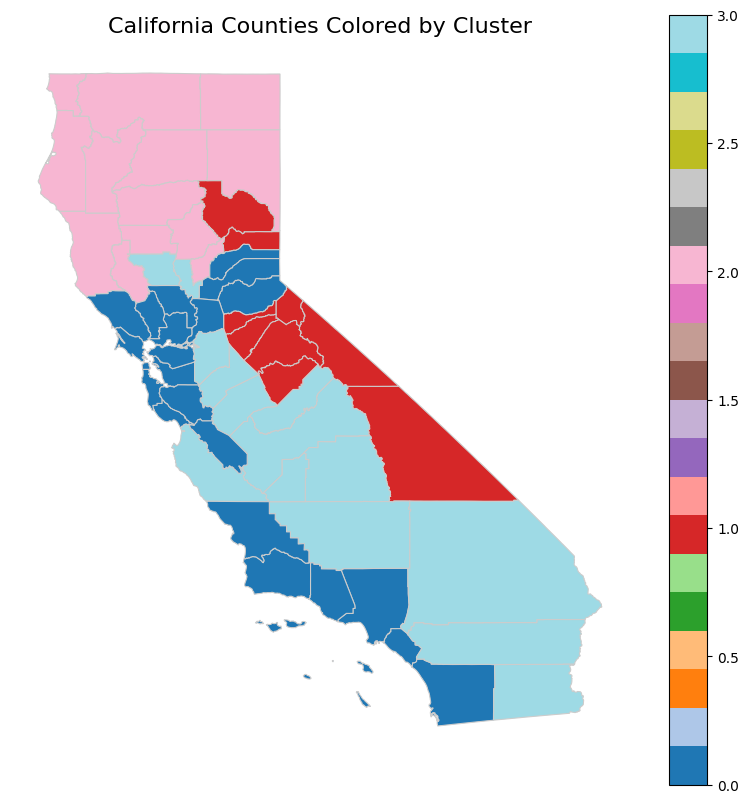

Found 12 missing values. Applying imputation.


/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/opt/a

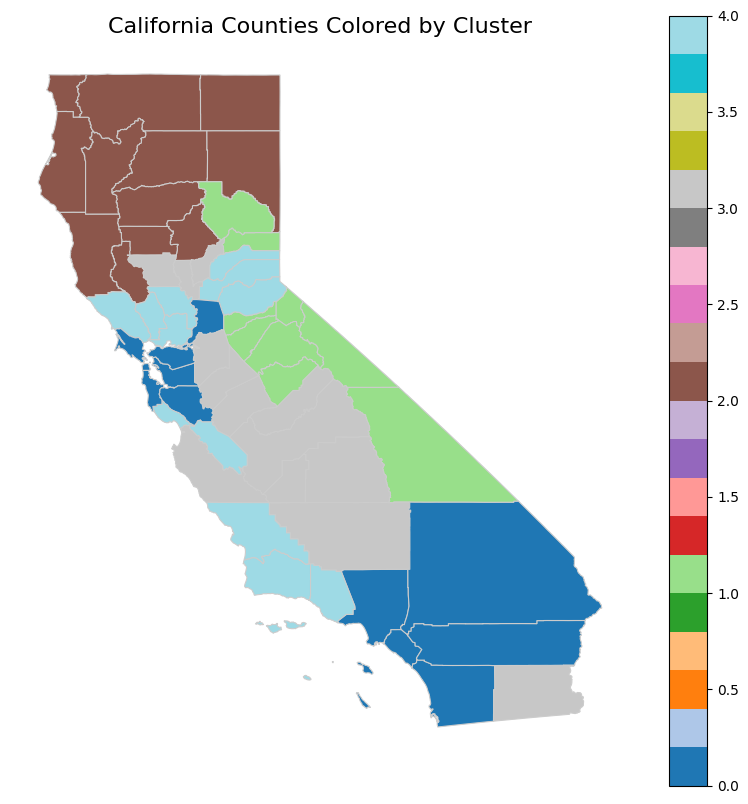

Found 12 missing values. Applying imputation.


/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/opt/a

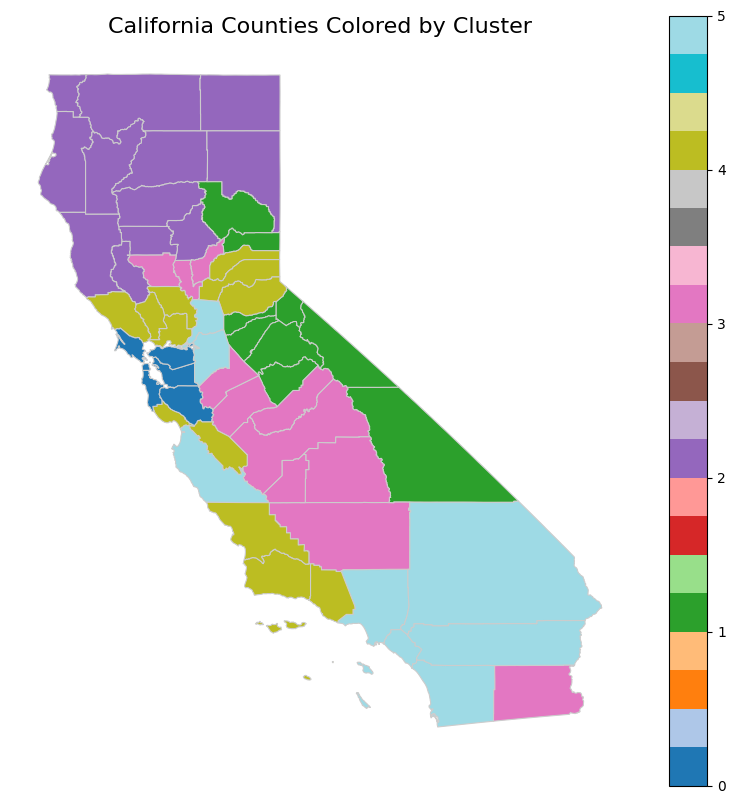

In [10]:
for num_clusters in [3, 4, 5, 6]:
    results = unsupervised_analysis(ca_count_df, n_clusters=num_clusters, plot = False)
    clustered_df = results['data_with_clusters']
    world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
    states = gpd.read_file("https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json")
    california = states[states['name'] == 'California']
    ca_counties_url = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/california-counties.geojson"
    ca_counties = gpd.read_file(ca_counties_url)


    area_cols = [col for col in clustered_df.columns if col.startswith('Area_Name_') or col.startswith('FIPS_')]
    clustered_df['county'] = clustered_df[area_cols].idxmax(axis=1)
    clustered_df['county'] = clustered_df['county'].str.replace('Area_Name_', '').str.strip()
    clustered_df = clustered_df.drop(columns=area_cols)


    ca_counties['name'] = ca_counties['name'].str.lower()
    clustered_df['county'] = clustered_df['county'].str.replace("FIPS_", "").str.strip()
    clustered_df['name'] = clustered_df['county'].map(fips_to_name).str.lower()
    merged = ca_counties.merge(clustered_df, on='name')


    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    merged.plot(column='UMAP_Cluster', cmap='tab20', linewidth=0.8, edgecolor='0.8', legend=True, ax=ax)
    ax.set_title("California Counties Colored by Cluster", fontsize=16)
    ax.axis("off")
    plt.show()


- add county names/ big cities to add more context to map
- remove natural change, maybe add separate maps for each important feature


---

### 🧠 Column Descriptions

| Column | Description |
|--------|-------------|
| `t_cap` | **Total capacity** of distributed energy resources (DERs) in a county — probably in kilowatts (kW). |
| `white` | **Percent of the population that is White** — already a proportion or percentage, so keep as is. |
| `black` | **Percent of the population that is Black** — already a proportion or percentage, so keep as is. |
| `Nameplate Capacity (in KW AC)` | **Installed solar system capacity** under ideal conditions, measured in kilowatts of AC output. |
| `Capacity_Latest` | Most **recent measure of system capacity** — probably also in kW (AC or DC unclear). |
| `System Size DC` | Total installed system capacity in **Direct Current**, typically used for solar PV sizing. |
| `System Size AC` | Installed solar system capacity in **Alternating Current**, typically smaller than DC rating. |
| `Storage Capacity (kWh)` | Total **energy capacity of batteries** — how much energy can be stored. |
| `Storage Size (kW AC)` | **Power output of storage systems**, i.e., how fast energy can be discharged. |
| `Inverter Size (kW AC)` | Total **capacity of inverters**, which convert DC to AC in solar/battery systems. |
| `Total System Cost` | **Upfront cost of energy systems** (likely solar/storage) in dollars. |
| `Itc Cost Basis` | **Cost basis eligible for federal tax credits** (Investment Tax Credit). |
| `Electric Vehicle Count` | Total number of **registered electric vehicles** in the county. |
| `DC Fast` | Number of **DC fast EV chargers** (very high-speed charging stations). |
| `Level 1` | Count of **Level 1 chargers**, standard home outlets. |
| `Level 2` | Count of **Level 2 chargers**, common in homes and public stations. |
| `Number of Chargers` | Total number of **EV chargers of all types**. |
| `GHI (kWh/m²/day)` | **Global Horizontal Irradiance** — solar radiation received per square meter daily. |
| `Wind Speed (10m) (m/s)` | **Average wind speed** at 10 meters height — used for estimating wind resource. |
| `Wind Speed (50m) (m/s)` | Same as above but at **50 meters**, closer to turbine hub height. |

---

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
df1 = pd.read_csv("california_energy_data.csv")
ca_count_df = pd.read_pickle("county_data_ca.pkl")
df1.fillna(0, inplace=True)
df1["FIPS"] = df1["FIPS"].astype(int).astype(str).str.zfill(5)
ca_count_df["FIPS"] = ca_count_df["FIPS"].astype(str).str.zfill(5)
df = df1.merge(ca_count_df, on="FIPS", how="outer")

# print(ca_count_df.columns)

per_capita_columns = [
    't_cap',
    'white', 'black', 'native', 'asian', 'pacific', 'other', 'two_or_more',
    'Nameplate Capacity (in KW AC)',
    'Capacity_Latest',
    'System Size DC',
    'System Size AC',
    'Storage Capacity (kWh)',
    'Storage Size (kW AC)',
    'Inverter Size (kW AC)',
    'Total System Cost',
    'Itc Cost Basis',
    'Electric Vehicle Count',
    'DC Fast', 'Level 1', 'Level 2',
    'Number of Chargers'
]

percent_columns = ['Percent of adults with less than a high school diploma, 2018-22',
    'Percent of adults with a high school diploma only, 2018-22',
    "Percent of adults completing some college or associate's degree, 2018-22",
    "Percent of adults with a bachelor's degree or higher, 2018-22",
    'Med_HH_Income_Percent_of_State_Total_2021', 'Unemployment_rate_2022',
    'PCTPOVALL_2021', 'R_NATURAL_CHG_2023',
    ]

unchanged_columns = [
    'FIPS', 'State', 'Area_Name',
    'GHI (kWh/m²/day)',
    'Wind Speed (10m) (m/s)', 'Wind Speed (50m) (m/s)',
    'Urban_Influence_Code_2013', '2023 Rural-urban Continuum Code',
    'POP_ESTIMATE_2023', 'NATURAL_CHG_2023', 'NET_MIG_2023',
    'GQ_ESTIMATES_2023', 'POVALL_2021',
    'Civilian_labor_force_2022',
    'Median_Household_Income_2021', 'lng', 'lat'
]


columns_to_keep = percent_columns + per_capita_columns + unchanged_columns + ['total_pop']
df_filtered = df[columns_to_keep].copy()

for col in per_capita_columns:
    df_filtered[col] = df_filtered[col] / df_filtered['total_pop']

for col in percent_columns:
    df_filtered[col] = df_filtered[col] / 100

df_normalized = df_filtered.drop(columns=['State', 'Area_Name'])


# Replace infinite values with NaN
df_normalized = df_normalized.replace([np.inf, -np.inf], np.nan)

# Fill NaNs only in numeric columns with the column mean
numeric_cols = df_normalized.select_dtypes(include=[np.number]).columns
df_normalized[numeric_cols] = df_normalized[numeric_cols].fillna(df_normalized[numeric_cols].mean())


```python
columns =  {0: 'Total Capacity per Capita', 
            1: 'White Population per Capita', 
            2: 'Black Population per Capita', 
            3: 'Nameplate Capacity (KW AC) per Capita', 
            4: 'Latest Capacity per Capita', 
            5: 'System Size DC per Capita', 
            6: 'System Size AC per Capita', 
            7: 'Storage Capacity (kWh) per Capita', 
            8: 'Storage Size (kW AC) per Capita', 
            9: 'Inverter Size (kW AC) per Capita', 
            10: 'Total System Cost per Capita', 
            11: 'ITC Cost Basis per Capita', 
            12: 'EV Count per Capita', 
            13: 'DC Fast Chargers per Capita', 
            14: 'Level 1 Chargers per Capita', 
            15: 'Level 2 Chargers per Capita', 
            16: 'Total Chargers per Capita', 
            17: 'Native Population per Capita', 
            18: 'Asian Population per Capita', 
            19: 'Pacific Islander Population per Capita', 
            20: 'Global Horizontal Irradiance (kWh/m²/day)', 
            21: 'Wind Speed at 10m (m/s)', 
            22: 'Wind Speed at 50m (m/s)', 
            23: 'Less than HS Diploma (%)', 
            24: 'Med HH Income (% of State)', 
            25: 'HS Diploma Only (%)', 
            26: 'Some College or Associate (%)', 
            27: 'Bachelor or Higher (%)'}

```

In [13]:
socio_cols = [
    'FIPS Code', 'Rural-Urban Continuum Code (2023)',
    'Less than HS Diploma (%)', 'HS Diploma Only (%)', 'Some College or Associate (%)',
    'Bachelor or Higher (%)', 'Population Estimate (2023)', 'Natural Change (2023)',
    'Net Migration (2023)', 'Group Quarters Estimate (2023)', 'Rural Natural Change (2023)',
    'Poverty All Population (2021)', 'Poverty All Population (%) (2021)',
    'Urban Influence Code (2013)', 'Civilian Labor Force (2022)', 'Unemployment Rate (2022)',
    'Median Household Income (2021)', 'Med HH Income (% of State)',
    'Total Population', 'White Population per Capita', 'Black Population per Capita',
    'Native Population per Capita', 'Asian Population per Capita', 'Pacific Islander Population per Capita',
    'Two or More Races Population per Capita' #, "Longitude", "Latitude"
]


rename_map = {
    't_cap': 'Total Capacity per Capita',
    'white': 'White Population per Capita',
    'black': 'Black Population per Capita',
    'Nameplate Capacity (in KW AC)': 'Nameplate Capacity (KW AC) per Capita',
    'Capacity_Latest': 'Latest Capacity per Capita',
    'System Size DC': 'System Size DC per Capita',
    'System Size AC': 'System Size AC per Capita',
    'Storage Capacity (kWh)': 'Storage Capacity (kWh) per Capita',
    'Storage Size (kW AC)': 'Storage Size (kW AC) per Capita',
    'Inverter Size (kW AC)': 'Inverter Size (kW AC) per Capita',
    'Total System Cost': 'Total System Cost per Capita',
    'Itc Cost Basis': 'ITC Cost Basis per Capita',
    'Electric Vehicle Count': 'EV Count per Capita',
    'DC Fast': 'DC Fast Chargers per Capita',
    'Level 1': 'Level 1 Chargers per Capita',
    'Level 2': 'Level 2 Chargers per Capita',
    'Number of Chargers': 'Total Chargers per Capita',
    'Percent of adults with less than a high school diploma, 2018-22': 'Less than HS Diploma (%)',
    'Med_HH_Income_Percent_of_State_Total_2021': 'Med HH Income (% of State)',
    'Percent of adults with a high school diploma only, 2018-22': 'HS Diploma Only (%)',
    "Percent of adults completing some college or associate's degree, 2018-22": 'Some College or Associate (%)',
    "Percent of adults with a bachelor's degree or higher, 2018-22": 'Bachelor or Higher (%)',
    'native': 'Native Population per Capita',
    'asian': 'Asian Population per Capita',
    'pacific': 'Pacific Islander Population per Capita',
    'GHI (kWh/m²/day)': 'Global Horizontal Irradiance (kWh/m²/day)',
    'Wind Speed (10m) (m/s)': 'Wind Speed at 10m (m/s)',
    'Wind Speed (50m) (m/s)': 'Wind Speed at 50m (m/s)',
    'FIPS': 'FIPS Code',
    'State': 'State Name',
    'Area_Name': 'Area Name',
    '2023 Rural-urban Continuum Code': 'Rural-Urban Continuum Code (2023)',
    'POP_ESTIMATE_2023': 'Population Estimate (2023)',
    'NATURAL_CHG_2023': 'Natural Change (2023)',
    'NET_MIG_2023': 'Net Migration (2023)',
    'GQ_ESTIMATES_2023': 'Group Quarters Estimate (2023)',
    'R_NATURAL_CHG_2023': 'Rural Natural Change (2023)',
    'POVALL_2021': 'Poverty All Population (2021)',
    'PCTPOVALL_2021': 'Poverty All Population (%) (2021)',
    'MEDHHINC_2021': 'Median Household Income (2021)',
    'Urban_Influence_Code_2013': 'Urban Influence Code (2013)',
    'Civilian_labor_force_2022': 'Civilian Labor Force (2022)',
    'Unemployment_rate_2022': 'Unemployment Rate (2022)',
    'Median_Household_Income_2021': 'Median Household Income (2021)',
    'total_pop': 'Total Population',
    'two_or_more': 'Two or More Races Population per Capita',
    'lng': "Longitude",
    'lat': "Latitude"
}

# Apply the renaming
df_normalized.rename(columns=rename_map, inplace=True)


### 📉 Dropped Columns due to High Multicollinearity (VIF = ∞)

```python
dropped_columns = {
    13: 'DC Fast Chargers per Capita',
    15: 'Level 2 Chargers per Capita',
    16: 'Total Chargers per Capita',
    23: 'Less than HS Diploma (%)',
    25: 'HS Diploma Only (%)',
    26: 'Some College or Associate (%)',
    27: 'Bachelor or Higher (%)'
}
```

### What is VIF?
VIF quantifies how much the variance of a regression coefficient is inflated due to multicollinearity with other predictors.

### What is multicolinearity?
Multicollinearity happens when two or more predictor variables (features) in your regression model are highly correlated. In other words, one can be linearly predicted from the others with a substantial degree of accuracy.

This is a problem because it:

- Makes it hard to interpret individual coefficients.
- Increases the variance of the coefficient estimates.
- Can make your model unstable and sensitive to small changes in the data.

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def reduce_multicollinearity(X_df, vif_threshold=10.0, verbose=True):
    """Automatically drops columns with high VIF iteratively."""
    dropped_features = []
    iteration = 0
    while True:
        # Scale features for VIF calculation
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_df)

        # Compute VIFs
        vif = pd.Series(
            [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])],
            index=X_df.columns
        )

        max_vif = vif.max()
        if max_vif > vif_threshold:
            max_feature = vif.idxmax()
            dropped_features.append(max_feature)
            X_df = X_df.drop(columns=[max_feature])
            iteration += 1
            if verbose:
                print(f"Iteration {iteration}: Dropped '{max_feature}' with VIF = {max_vif:.2f}")
        else:
            if verbose:
                print("\nAll remaining features have VIF below threshold.")
            break

    return X_df, dropped_features


X_reduced, dropped = reduce_multicollinearity(df_normalized[socio_cols], vif_threshold=10.0)
X_scaled = StandardScaler().fit_transform(X_reduced)
print("\nDropped due to high VIF:", dropped)

# Compute VIF on scaled data
vif_data = pd.DataFrame()
vif_data["feature"] = X_reduced.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]

print("\nVariance Inflation Factors (VIF):")
print(vif_data.sort_values(by="VIF", ascending=False))
# X_reduced = df_normalized[socio_cols]
# X_reduced = X_reduced.rename(dict(enumerate(df_normalized.columns)))
# print(X_reduced.columns)
# print(dict(enumerate(df_normalized.columns)))

Iteration 1: Dropped 'Less than HS Diploma (%)' with VIF = inf
Iteration 2: Dropped 'Med HH Income (% of State)' with VIF = 1021039.31
Iteration 3: Dropped 'Civilian Labor Force (2022)' with VIF = 41660.11
Iteration 4: Dropped 'Population Estimate (2023)' with VIF = 1799.86
Iteration 5: Dropped 'Group Quarters Estimate (2023)' with VIF = 298.78
Iteration 6: Dropped 'Poverty All Population (2021)' with VIF = 204.73
Iteration 7: Dropped 'Net Migration (2023)' with VIF = 38.49
Iteration 8: Dropped 'Bachelor or Higher (%)' with VIF = 35.04
Iteration 9: Dropped 'Median Household Income (2021)' with VIF = 23.36
Iteration 10: Dropped 'White Population per Capita' with VIF = 13.89
Iteration 11: Dropped 'Rural-Urban Continuum Code (2023)' with VIF = 11.51

All remaining features have VIF below threshold.

Dropped due to high VIF: ['Less than HS Diploma (%)', 'Med HH Income (% of State)', 'Civilian Labor Force (2022)', 'Population Estimate (2023)', 'Group Quarters Estimate (2023)', 'Poverty All 

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:198: RuntimeWarning:

divide by zero encountered in scalar divide



### Notes:
- Tried multiple VIF values, 1, 10, 100, 1000 with the socio-economic factors and with everything


- non-linear models: decision trees, boosting trees (XG Boost), gaussian mixture models  
- look into feature engineering: ways to combine the features 
- filling data with clustering/kNN, look into other datasets that have the same data
- Try using other methods to tune the hyperparameters - grid search or random search

In [15]:
# target = "Total Capacity per Capita"
# target = "System Size DC per Capita"
target = "EV Count per Capita"
# target = 'Nameplate Capacity (KW AC) per Capita'
# target = 'Storage Capacity (kWh) per Capita'
# target = 'Total Chargers per Capita'


# print(X_reduced.head)
X_reduced.drop(columns = ["Latest Capacity per Capita", "Total Capacity per Capita"], inplace=True, errors = "ignore")
new = X_reduced.copy()
new[target] = df_normalized[target].copy()
corr = new.corr()
print(corr[target].sort_values(ascending=False))


from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')  # Replace 'mean' with other strategies if needed
X = pd.DataFrame(imputer.fit_transform(X_reduced))
y = df_normalized[target].copy()


EV Count per Capita                        1.000000
Asian Population per Capita                0.365229
Pacific Islander Population per Capita     0.160767
Rural Natural Change (2023)                0.085350
FIPS Code                                  0.019073
Black Population per Capita                0.015456
Natural Change (2023)                     -0.027933
Total Population                          -0.070717
Two or More Races Population per Capita   -0.092491
Native Population per Capita              -0.239473
Some College or Associate (%)             -0.302072
Urban Influence Code (2013)               -0.326384
Unemployment Rate (2022)                  -0.399347
HS Diploma Only (%)                       -0.543838
Poverty All Population (%) (2021)         -0.652430
Name: EV Count per Capita, dtype: float64


add intercepts


Model Performance (R² Scores):
Coefficients:
 0    -0.000494
1    -0.000821
2    -0.000508
3    -0.000221
4    -0.000823
5    -0.001270
6    -0.000216
7    -0.000181
8    -0.000612
9     0.000070
10   -0.000693
11   -0.000346
12    0.000120
13    0.000345
dtype: float64
R² Score: 0.2589499775694394
Ridge R² on test set: 0.260
Ridge CV R² scores: [  0.14226297   0.71496016 -70.53695478   0.46103697  -0.91283049
  -1.02996082  -0.44082819   0.60099431   0.62628997 -13.88876944]
Ridge mean CV R²: -8.426
Ridge Coefficients:
13    0.000344
12    0.000120
9     0.000069
7    -0.000181
6    -0.000216
3    -0.000221
11   -0.000345
0    -0.000494
2    -0.000507
8    -0.000612
10   -0.000692
4    -0.000820
1    -0.000821
5    -0.001269
dtype: float64


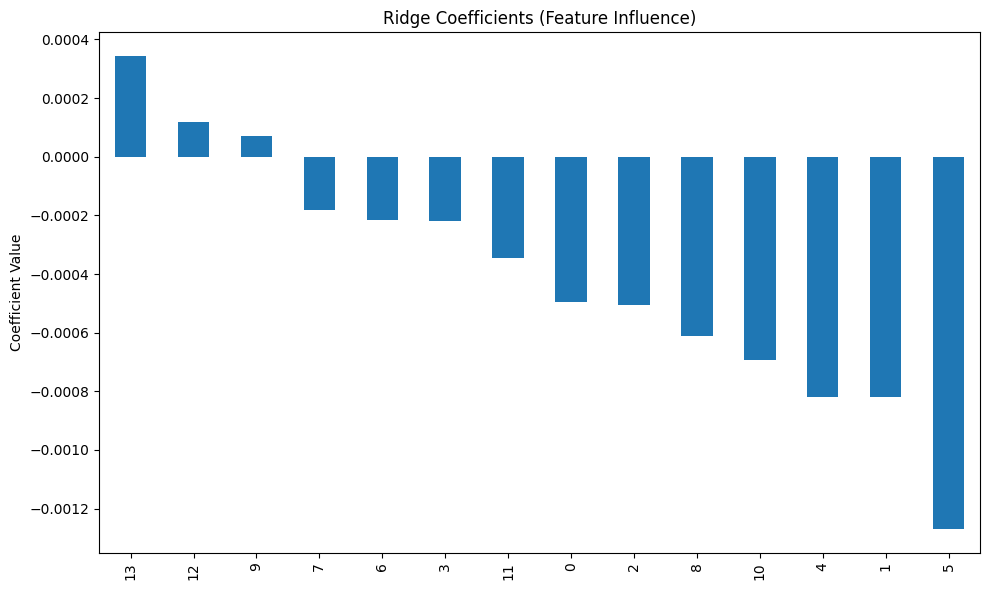

{0: 'FIPS Code', 1: 'HS Diploma Only (%)', 2: 'Some College or Associate (%)', 3: 'Natural Change (2023)', 4: 'Rural Natural Change (2023)', 5: 'Poverty All Population (%) (2021)', 6: 'Urban Influence Code (2013)', 7: 'Unemployment Rate (2022)', 8: 'Total Population', 9: 'Black Population per Capita', 10: 'Native Population per Capita', 11: 'Asian Population per Capita', 12: 'Pacific Islander Population per Capita', 13: 'Two or More Races Population per Capita'}


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------

print("\nModel Performance (R² Scores):")
valid_rows = np.isfinite(y)
X_clean = X_scaled[valid_rows]
y_clean = y[valid_rows]
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

# Train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
coefficients = pd.Series(model.coef_, index=X.columns)
print("Coefficients:\n", coefficients)
print("R² Score:", r2)



# Ridge Regression
ridge = Ridge(alpha=0.01, fit_intercept=True, max_iter=100000)  # Try different alpha values
ridge.fit(X_train, y_train)
ridge_r2 = ridge.score(X_test, y_test)
print(f"Ridge R² on test set: {ridge_r2:.3f}")
# # cross validation scores
# alphas = np.logspace(1, 10, 100)
# ridge_cv = RidgeCV(alphas=alphas, scoring='r2', cv=5)
# ridge_cv.fit(X_train, y_train)
# print("Best alpha:", ridge_cv.alpha_)


ridge_cv_scores = cross_val_score(ridge, X_clean, y_clean, cv=10, scoring='r2')
print(f"Ridge CV R² scores: {ridge_cv_scores}")
print(f"Ridge mean CV R²: {ridge_cv_scores.mean():.3f}")
# ridge coefficients
ridge_coef = pd.Series(ridge.coef_, index=X.columns)
ridge_coef = ridge_coef.sort_values(ascending=False)
print("Ridge Coefficients:")
print(ridge_coef)


# plotting the features to see which ones matter most
plt.figure(figsize=(10, 6))
ridge_coef.plot(kind='bar')
plt.title("Ridge Coefficients (Feature Influence)")
plt.ylabel("Coefficient Value")
plt.tight_layout()
plt.show()

print(dict(enumerate(X_reduced.columns)))


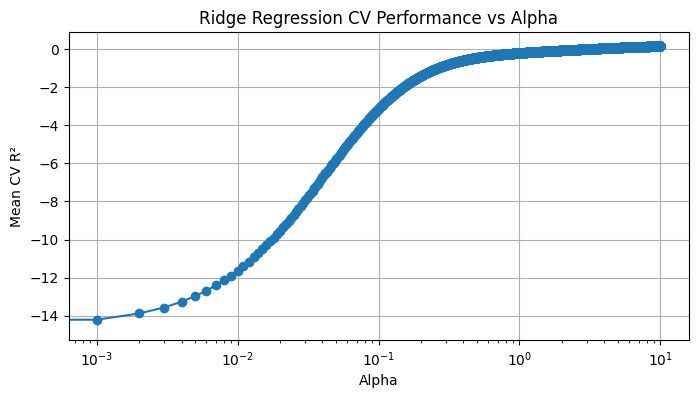

In [17]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

alphas = [0.001 * i for i in range(10000)]
cv_scores = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha, fit_intercept=True)
    scores = cross_val_score(ridge, X_train, y_train, scoring='r2', cv=5)
    cv_scores.append(scores.mean())

plt.figure(figsize=(8, 4))
plt.plot(alphas, cv_scores, marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Mean CV R²')
plt.title('Ridge Regression CV Performance vs Alpha')
plt.grid(True)
plt.show()

A **Random Forest Regressor** is an ensemble learning method used for regression tasks (predicting continuous values). It combines multiple decision trees to produce a more accurate and stable prediction. Here's a breakdown of how it works:

#### Advantages:

* **Reduces Overfitting**: By averaging many trees, Random Forest can handle overfitting that often happens in individual decision trees.
* **Handles High-Dimensional Data**: It works well with a large number of features, thanks to the random selection of features at each split.
* **Handles Missing Data**: Random Forest can handle missing values relatively well.
* **Non-linear Relationships**: It can capture non-linear relationships between features and the target variable.
* **Feature Importance**: Random Forest can provide insights into which features are most important for making predictions.


#### Key Parameters in RandomForestRegressor:

* `n_estimators`: Number of trees in the forest (higher values usually improve performance but take longer to compute).
* `max_features`: Number of features to consider at each split (usually the square root of the number of features works well).
* `max_depth`: The maximum depth of each tree (controls how complex the model can be).
* `min_samples_split`: The minimum number of samples required to split a node.
* `random_state`: A seed for reproducibility.


* **Feature Importance**: After training the model, you can check which features are most important in making predictions by looking at the `feature_importances_` attribute. Higher values indicate more important features.

Random Forest is particularly useful when you want a robust, high-performance model that can handle large datasets and a variety of data types without needing to manually tune many parameters.


Random Forest R² on test set: 0.536
RF CV R² scores: [ 0.37383317  0.81501294 -1.67653022  0.35555456 -1.13000374 -0.53456862
 -0.04972363  0.41222141  0.67739469 -2.12606504]
RF mean CV R²: -0.288
Random Forest Feature Importances:
6     0.005549
11    0.011109
8     0.016784
13    0.016910
0     0.018334
12    0.018802
4     0.030548
3     0.033175
9     0.034025
2     0.039633
10    0.058142
1     0.089539
7     0.144326
5     0.483124
dtype: float64


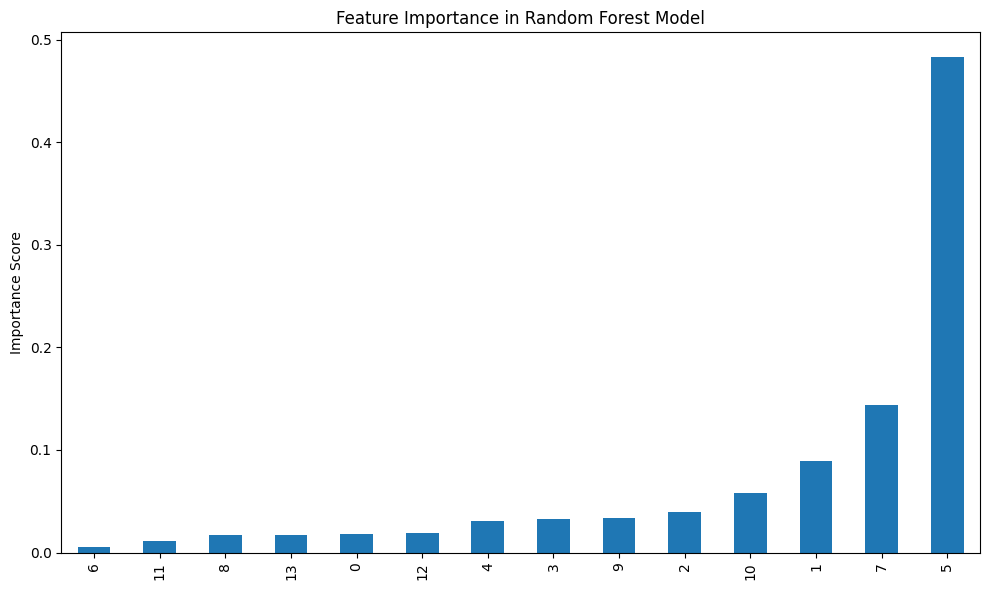

In [18]:

# trying Random Forest regressor
rf = RandomForestRegressor(
    criterion="squared_error",
    n_estimators=100,  # number of trees
    max_depth=None,    # maximum depth of trees
    min_samples_split=2,
    random_state=42
)
rf.fit(X_train, y_train)

# Evaluate performance
rf_r2 = rf.score(X_test, y_test)
print(f"Random Forest R² on test set: {rf_r2:.3f}")

# Cross-validation
rf_cv_scores = cross_val_score(rf, X_clean, y_clean, cv=10, scoring='r2')
print(f"RF CV R² scores: {rf_cv_scores}")
print(f"RF mean CV R²: {rf_cv_scores.mean():.3f}")


# to see the feature importances
rf_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)
print("Random Forest Feature Importances:")
print(rf_importance)
plt.figure(figsize=(10, 6))
rf_importance.plot(kind='bar')
plt.title('Feature Importance in Random Forest Model')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

### 🔧 **Lasso Regression (Least Absolute Shrinkage and Selection Operator)**

* **What it does:**
  Adds an **L1 penalty** (sum of absolute coefficients) to the loss function.

* **Why it's useful:**
  It **shrinks some coefficients exactly to zero**, which means it automatically performs **feature selection**. This makes models simpler and helps with **overfitting**, especially when you have many features.

---

### 🔧 **Elastic Net Regression**

* **What it does:**
  Combines **L1 penalty (like Lasso)** and **L2 penalty (like Ridge)** in a single model.

* **Why it's useful:**
  It balances between **sparse models (Lasso)** and **shrinkage (Ridge)**. It's especially helpful when:

  * You have **many correlated features**
  * You want both **feature selection** and **coefficient stability**


In [19]:
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

# LASSO
lasso = Lasso(alpha=0.001, fit_intercept=True)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

# Elastic Net
elastic = ElasticNet(alpha=0.001, l1_ratio=0.5, fit_intercept=True)  # l1_ratio=1 is Lasso, 0 is Ridge
elastic.fit(X_train, y_train)
y_pred_elastic = elastic.predict(X_test)


def evaluate_model(name, y_true, y_pred):
    print(f"\n{name}")
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("R²:", r2_score(y_true, y_pred))

evaluate_model("Lasso", y_test, y_pred_lasso)
evaluate_model("Elastic Net", y_test, y_pred_elastic)



Lasso
MSE: 2.5306071965080434e-06
R²: 0.3811262388842668

Elastic Net
MSE: 1.977755769604224e-06
R²: 0.5163290638735771


In [20]:

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LassoCV, ElasticNetCV

lasso_cv = LassoCV(cv=10, random_state=42)
lasso_cv.fit(X_train, y_train)
y_pred_lasso_cv = lasso_cv.predict(X_test)

print("Best alpha for Lasso:", lasso_cv.alpha_)
print("LassoCV MSE:", mean_squared_error(y_test, y_pred_lasso_cv))
print("LassoCV R²:", r2_score(y_test, y_pred_lasso_cv))

# print("Number of non-zero Lasso coefficients: ", np.sum(lasso_cv.coef_ != 0))
# param_grid = {'alphas': [0.01, 0.1, 1, 10, 100, 1000]}
# grid = GridSearchCV(estimator=lasso_cv, param_grid=param_grid, scoring='r2', cv=5)
# grid.fit(X_train, y_train)

# best_params = grid.best_params_
# best_model = grid.best_estimator_
# y_pred = best_model.predict(X_test, y_test)


elastic_cv = ElasticNetCV(cv=10, l1_ratio=[.1, .5, .7, .9, .95, 1]).fit(X_train, y_train)
elastic_cv.fit(X_train, y_train)
y_pred_elastic_cv= elastic_cv.predict(X_test)
print("\n Best alpha for elastic_cv:", elastic_cv.alpha_)
print("elastic_cv MSE:", mean_squared_error(y_test, y_pred_elastic_cv))
print("elastic_cv R²:", r2_score(y_test, y_pred_elastic_cv))


Best alpha for Lasso: 0.00026023299753843185
LassoCV MSE: 2.0445315195077685e-06
LassoCV R²: 0.4999986908503933

 Best alpha for elastic_cv: 0.00026023299753843185
elastic_cv MSE: 2.0445315195077685e-06
elastic_cv R²: 0.4999986908503933


In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

param_grid = {'regr__alpha': np.logspace(-4, 2, 10),
              'regr': [Lasso(), Ridge()]}
# what is a pipeline?
# a way of organizing and executing multiple machine learning steps in a sequential manner.
pipeline = Pipeline([('scaler', StandardScaler()),
                     ('regr', Lasso())])  # or use Lasso()
gscv = GridSearchCV(pipeline, param_grid, scoring='neg_mean_squared_error', cv=5)
gscv.fit(X, y)

# Print the results
print(gscv.best_params_)
print(gscv.best_score_)
print(gscv.best_estimator_)

{'regr': Lasso(alpha=0.00046415888336127773), 'regr__alpha': 0.00046415888336127773}
-4.11175239371575e-06
Pipeline(steps=[('scaler', StandardScaler()),
                ('regr', Lasso(alpha=0.00046415888336127773))])


In [22]:
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

lasso = Lasso(alpha=0.1, fit_intercept=False)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

# --- Elastic Net Regression ---
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5, fit_intercept=False)  # l1_ratio=1 is Lasso, 0 is Ridge
elastic.fit(X_train, y_train)
y_pred_elastic = elastic.predict(X_test)

# --- Evaluation ---
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name}")
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("R²:", r2_score(y_true, y_pred))

evaluate_model("Lasso", y_test, y_pred_lasso)
evaluate_model("Elastic Net", y_test, y_pred_elastic)


Lasso
MSE: 8.895840719461894e-06
R²: -1.1755262578628227

Elastic Net
MSE: 8.895840719461894e-06
R²: -1.1755262578628227


| Term                   | Meaning                                                                               |
| ---------------------- | ------------------------------------------------------------------------------------- |
| **Dep. Variable**      | The response you're predicting — here, `"EV Count per Capita"`                        |
| **R-squared**          | Proportion of variance in the target explained by the model (0.672 = 67.2%)           |
| **Adj. R-squared**     | Adjusted for number of predictors; penalizes model complexity (0.465)                 |
| **F-statistic**        | Tests whether at least one predictor has a non-zero coefficient                       |
| **Prob (F-statistic)** | p-value for F-test; small value (here, 0.000580) → model is statistically significant |
| **No. Observations**   | Number of rows in your data (63 rows)                                                 |
| **Df Model**           | Number of predictors (24)                                                             |
| **Df Residuals**       | Degrees of freedom left (63 – 25 = 38), where 25 includes intercept                   |
| **AIC / BIC**          | Model quality metrics; lower = better, penalize overfitting                           |

| Column              | Meaning                                        | 
| ------------------- | ---------------------------------------------- |
| **coef**            | Estimated coefficient (slope) for the variable |    
| **std err**         | Standard error of the coefficient estimate     |  
| **t**               | t-statistic = coef / std err                   |  
| \*\*P>              | t: p-value for the hypothesis test: H₀: coef = 0 |
| **\[0.025, 0.975]** | 95% confidence interval for the coefficient    |



In [23]:
# using stats models
# Means OLS assumes residuals are homoscedastic (constant variance) and uncorrelated.
import statsmodels.api as sm

X = sm.add_constant(X_clean)
y = y_clean

model = sm.OLS(y, X).fit(cov_type='HC1') # HC accounts for heterskedasticity - differing variance across x values, spread of data across regression line isnt uniform
print(model.summary())

print(model.params.index)


                             OLS Regression Results                            
Dep. Variable:     EV Count per Capita   R-squared:                       0.594
Model:                             OLS   Adj. R-squared:                  0.475
Method:                  Least Squares   F-statistic:                     7.149
Date:                 Wed, 14 May 2025   Prob (F-statistic):           1.15e-07
Time:                         10:50:23   Log-Likelihood:                 317.46
No. Observations:                   63   AIC:                            -604.9
Df Residuals:                       48   BIC:                            -572.8
Df Model:                           14                                         
Covariance Type:                   HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0022      0.000      9.81

In [24]:
# testing for heteroskedasticity
from statsmodels.stats.diagnostic import het_breuschpagan

residuals = model.resid
exog = model.model.exog  # the independent variables (including intercept)

bp_test = het_breuschpagan(residuals, exog)
labels = ['LM stat', 'LM p-value', 'F-stat', 'F p-value']
dict(zip(labels, bp_test))

{'LM stat': 23.449147441111332,
 'LM p-value': 0.0533425920212674,
 'F-stat': 2.0327520581572056,
 'F p-value': 0.034941760082521436}

#### ECON ML

#### What is a **Treatment** in Causal Inference?

A **treatment** is the thing you’re testing the *effect* of.
It’s a variable you believe might **cause** a change in your outcome.

* If you were studying a **medical trial**, treatment might be: `got_drug = 1` or `0`.
* In your case (social factors + energy/EVs), treatment could be:

  * **“Does a county have high median income?”**
  * **“What is the level of urbanization?”**
  * **“Has the area received a clean energy grant?”**

The **treatment** doesn’t have to be binary — it can also be continuous (like income level), as long as you're asking how a *change* in that variable causes a change in the outcome.

---

#### Basic Anatomy of Causal Estimation (e.g. with `econml.LinearDML`)

Let's say we want to estimate:

> “What is the effect of income on EV ownership per capita?”

##### 1. **Inputs you provide:**

* `Y`: your outcome (e.g. EVs per capita)
* `T`: your treatment (e.g. median income)
* `X`: other variables that affect both Y and T — **confounders** (e.g. education, urbanization)

##### 2. **econml estimates two models** using ML (like Lasso):

* One to predict **Y from X**: outcome model
  (*what you'd expect EVs to be based on confounders*)
* One to predict **T from X**: treatment model
  (*what you'd expect income to be based on confounders*)

It subtracts both predictions from the actual data (called **residualization**), to isolate the part of T and Y *not explained* by X.

```python
# Residualized Y = Y - predicted_Y
# Residualized T = T - predicted_T
```

##### 3. **It then runs a linear regression** of the residualized Y on residualized T:

> That gives you a **causal estimate** of how T affects Y, holding X constant.

---

#### 🔹 Summary of Key Terms

| Term          | What it means                                                        |
| ------------- | -------------------------------------------------------------------- |
| Treatment (T) | The variable you're testing for causal effect (e.g. income)          |
| Outcome (Y)   | The result you're trying to explain (e.g. EV ownership)              |
| Controls (X)  | Confounding variables to adjust for                                  |
| Effect (TE)   | The estimated causal impact of T on Y                                |
| DML           | Uses machine learning to "partial out" confounding before regression |

---

#### ✅ When is this useful for *you*?

If you're looking to answer questions like:

* “Does urbanization cause more EVs?”
* “Does education level influence clean tech adoption?”
* “What’s the *causal effect* of income on energy behavior?”
* helps us estimate the causal effect of T on Y controlling for X

| Column                  | Meaning                                                         |
| ----------------------- | --------------------------------------------------------------- |
| `point_estimate`        | How much this covariate modifies the treatment effect of income |
| `stderr`                | Standard error (uncertainty)                                    |
| `zstat`                 | Z-statistic for the test (estimate ÷ std error)                 |
| `pvalue`                | P-value for significance                                        |
| `ci_lower` & `ci_upper` | 95% confidence interval for the estimate                        |
|`CATE Intercept` | The baseline average treatment effect (ATE) when all covariates are zero|

In [25]:
from econml.dml import LinearDML
from sklearn.linear_model import LassoCV
scaler = StandardScaler()


Y = df_normalized["EV Count per Capita"] # outcome
T = df_normalized["Median Household Income (2021)"] # what we are controlling for
T_scaled = scaler.fit_transform(T.values.reshape(-1, 1)).ravel()
X = X_reduced.copy()

model = LinearDML(
    model_y=LassoCV(cv=10), # cv is the number of folds
    model_t=LassoCV(cv=10),
    random_state=42
)
model.fit(Y, T_scaled, X=X_clean)
ate = model.ate(X=X_clean)

print(f"Estimated Average Treatment Effect of Income on EV Adoption: {ate:.4f}")
print(model.summary())

Estimated Average Treatment Effect of Income on EV Adoption: 0.0030
                   Coefficient Results                   
    point_estimate stderr zstat  pvalue ci_lower ci_upper
---------------------------------------------------------
X0          -0.001  0.001 -0.676  0.499   -0.003    0.001
X1           0.001  0.001  0.944  0.345   -0.001    0.003
X2            -0.0  0.001 -0.198  0.843   -0.002    0.002
X3           0.011  0.005  2.095  0.036    0.001    0.022
X4           0.001  0.002  0.498  0.618   -0.003    0.005
X5          -0.001  0.001 -0.999  0.318   -0.004    0.001
X6          -0.001  0.001 -1.597   0.11   -0.003      0.0
X7          -0.001  0.001 -0.658   0.51   -0.002    0.001
X8          -0.003  0.001  -2.08  0.038   -0.006     -0.0
X9          -0.001  0.001 -0.601  0.548   -0.003    0.002
X10           -0.0  0.001 -0.449  0.653   -0.002    0.001
X11         -0.002  0.001 -1.871  0.061   -0.004      0.0
X12            0.0    0.0  0.178  0.859   -0.001    0.001
X13 

Model LassoCV(cv=10) has a non-default cv attribute, which will be ignored
Model LassoCV(cv=10) has a non-default cv attribute, which will be ignored


#### k-Nearest Neighbors

In [26]:
from sklearn.neighbors import KNeighborsRegressor

knn_regressor = KNeighborsRegressor(n_neighbors=18)
knn_regressor.fit(X_train, y_train)
y_pred = knn_regressor.predict(X_test)
mse = np.sum((np.array(y_test) - np.array(y_pred))** 2)
# print(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse:.5f}')
print(f'R² Score: {r2:.2f}')

Mean Squared Error: 0.00003
R² Score: 0.43


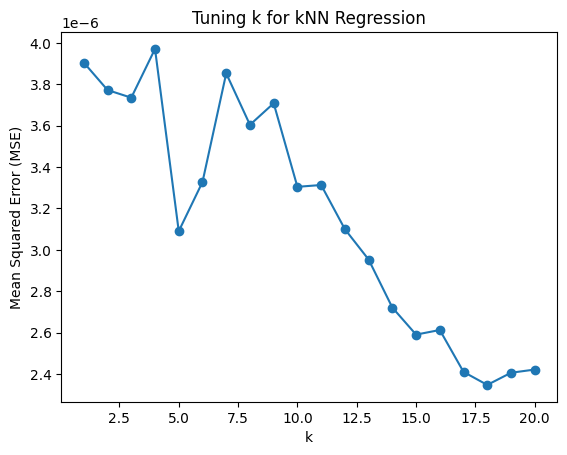

Best k: 18


In [27]:

# finding best value for k
k_values = range(1, 21)  # test k from 1 to 20
errors = []

for k in k_values:
    knn_regressor = KNeighborsRegressor(n_neighbors=k)
    knn_regressor.fit(X_train, y_train)
    y_pred = knn_regressor.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    errors.append(mse)

# plot errors to find the best k
import matplotlib.pyplot as plt
plt.plot(k_values, errors, marker='o')
plt.xlabel('k')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Tuning k for kNN Regression')
plt.show()

# find the best k
best_k = k_values[np.argmin(errors)]
print(f"Best k: {best_k}")

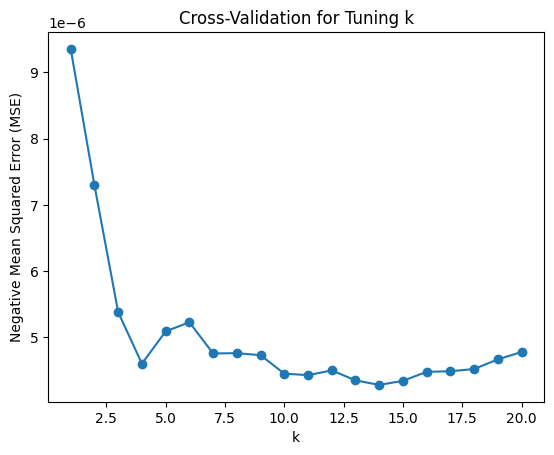

Best k: 14


In [28]:
from sklearn.model_selection import cross_val_score

k_values = range(1, 21)
mean_scores = []

for k in k_values:
    knn_regressor = KNeighborsRegressor(n_neighbors=k)
    scores = cross_val_score(knn_regressor, X_scaled, y, cv=5, scoring='neg_mean_squared_error')
    mean_scores.append(np.mean(scores))

plt.plot(k_values, -np.array(mean_scores), marker='o')
plt.xlabel('k')
plt.ylabel('Negative Mean Squared Error (MSE)')
plt.title('Cross-Validation for Tuning k')
plt.show()

# find the best k
best_k = k_values[np.argmax(mean_scores)]
print(f"Best k: {best_k}")


### Linear Models Package
 The linearmodels package is deisgned for panel data where data is over time and not cross-sectional.
 To solve this, I can look for data from previous time periods and interpolate.

In [29]:
"""
import pandas as pd
from linearmodels.panel import PanelOLS
model = PanelOLS(y, X, entity_effects=True)
result = model.fit()
print(result.summary())
"""

'\nimport pandas as pd\nfrom linearmodels.panel import PanelOLS\nmodel = PanelOLS(y, X, entity_effects=True)\nresult = model.fit()\nprint(result.summary())\n'

In [30]:
"""
from linearmodels.panel import RandomEffects

model_re = RandomEffects(y, X)
result_re = model_re.fit()
print(result_re.summary())
"""

'\nfrom linearmodels.panel import RandomEffects\n\nmodel_re = RandomEffects(y, X)\nresult_re = model_re.fit()\nprint(result_re.summary())\n'

* write a summary of what each package does and why we aren't able to use it
- for fixed  and random effects, also for iv
- look into more packages/ways to analyze panel data
- look into 5-10 papers that look into factors of DER penetration  (more focused on socioeconomics): see if our research has been done before, or if their process can be used for our research 

In [31]:
"""
from linearmodels.panel import IVLIM
# Fit IV regression model
iv_model = IVLIM(y, X, Z_iv)
iv_result = iv_model.fit()

# Display results
print(iv_result.summary())
"""

'\nfrom linearmodels.panel import IVLIM\n# Fit IV regression model\niv_model = IVLIM(y, X, Z_iv)\niv_result = iv_model.fit()\n\n# Display results\nprint(iv_result.summary())\n'

In [32]:
"""
correlation_matrix = X_clean.corr()
print(corr["white"].sort_values(ascending=False))
pearson_corr = correlation_matrix.corr(method='pearson')
spearman_corr = correlation_matrix.corr(method='spearman')

for col in per_capita_columns:
    try:
        print(correlation_matrix[f'{col}_per_capita'])
    except:
        pass


plt.figure(figsize=(12, 12))
sns.heatmap(X, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()
"""
# plt.figure(figsize=(10, 8))
# sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
# plt.title("Spearman Correlation Matrix")
# plt.tight_layout()
# plt.show()


'\ncorrelation_matrix = X_clean.corr()\nprint(corr["white"].sort_values(ascending=False))\npearson_corr = correlation_matrix.corr(method=\'pearson\')\nspearman_corr = correlation_matrix.corr(method=\'spearman\')\n\nfor col in per_capita_columns:\n    try:\n        print(correlation_matrix[f\'{col}_per_capita\'])\n    except:\n        pass\n\n\nplt.figure(figsize=(12, 12))\nsns.heatmap(X, annot=True, cmap="coolwarm", vmin=-1, vmax=1)\nplt.title("Correlation Matrix")\nplt.tight_layout()\nplt.show()\n'